# FX ML Pipeline — Sliding-Window Walk-Forward Validation (Ranking)

This notebook:
1. Loads `fx_features_wide.csv` from Google Drive.
2. Re-computes **future multi-day returns** from the `ret_*` features (no precomputed targets needed).
3. Converts the data to **long ranking format** (one row per date–pair).
4. Runs **LightGBM ranker** with a **sliding-window walk-forward** scheme.
5. Evaluates performance using **NDCG@K** and **PnL curves** for Top-1/3/5 strategies.


## 1. Setup & Imports
Make sure your `fx_features_wide.csv` is stored at:
`/content/drive/My Drive/Home/Forex/fx_features_wide.csv`
(the same path you used before).

In [5]:
# Install LightGBM if not already available
!pip install lightgbm -q

import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRanker
from sklearn.metrics import ndcg_score
import matplotlib.pyplot as plt

# Display options
pd.set_option("display.max_columns", 200)


## 2. Load Wide Feature Matrix

In [6]:
# Path to your wide feature CSV on Google Drive
CSV_PATH = "fx_features_wide.csv"

# Load
df = pd.read_csv(CSV_PATH)
df["Date"] = pd.to_datetime(df["Date"], utc=True)
df = df.sort_values("Date").reset_index(drop=True)

print("Wide shape:", df.shape)
print("Columns:", df.columns[:20], "...")


Wide shape: (906, 124)
Columns: Index(['Date', 'ret_AUDCAD=X', 'ret_AUDCHF=X', 'ret_AUDJPY=X', 'ret_AUDNZD=X',
       'ret_AUDUSD=X', 'ret_CADCHF=X', 'ret_CADJPY=X', 'ret_EURCAD=X',
       'ret_EURCHF=X', 'ret_EURGBP=X', 'ret_EURJPY=X', 'ret_EURNZD=X',
       'ret_EURUSD=X', 'ret_GBPCAD=X', 'ret_GBPCHF=X', 'ret_GBPJPY=X',
       'ret_GBPUSD=X', 'ret_NZDCAD=X', 'ret_NZDCHF=X'],
      dtype='object') ...


## 3. Identify Pairs and Compute Future Returns

In [7]:
# Detect FX pairs from return columns
ret_cols = [c for c in df.columns if c.startswith("ret_")]
pairs = [c.replace("ret_", "") for c in ret_cols]
print("Detected pairs:", pairs)

# Horizon for future returns (e.g., 5-day forward sum of daily returns)
HORIZON = 5

# Matrix of current returns
ret_mat = df[ret_cols].copy()

# Rolling HORIZON-day sum, shifted up to represent future returns
future_mat = (
    ret_mat
    .rolling(window=HORIZON, min_periods=HORIZON)
    .sum()
    .shift(-HORIZON)
)

# Keep only rows where all pairs have defined future returns
valid_mask = ~future_mat.isna().any(axis=1)
df = df.loc[valid_mask].reset_index(drop=True)
future_mat = future_mat.loc[valid_mask].reset_index(drop=True)

print("Rows after future-return trim:", df.shape[0])

# Attach future_ret_<pair> columns
for col in ret_cols:
    pair = col.replace("ret_", "")
    df[f"future_ret_{pair}"] = future_mat[col]

# FIXED: correct preview of future_ret_* columns
future_cols = [c for c in df.columns if c.startswith("future_ret_")]
print("Sample of future_ret columns:")
print(df[future_cols].head(1))


Detected pairs: ['AUDCAD=X', 'AUDCHF=X', 'AUDJPY=X', 'AUDNZD=X', 'AUDUSD=X', 'CADCHF=X', 'CADJPY=X', 'EURCAD=X', 'EURCHF=X', 'EURGBP=X', 'EURJPY=X', 'EURNZD=X', 'EURUSD=X', 'GBPCAD=X', 'GBPCHF=X', 'GBPJPY=X', 'GBPUSD=X', 'NZDCAD=X', 'NZDCHF=X', 'NZDJPY=X', 'NZDUSD=X', 'USDCAD=X', 'USDCHF=X', 'USDJPY=X']
Rows after future-return trim: 901
Sample of future_ret columns:
   future_ret_AUDCAD=X  future_ret_AUDCHF=X  future_ret_AUDJPY=X  \
0            -0.002824             0.019642             0.036708   

   future_ret_AUDNZD=X  future_ret_AUDUSD=X  future_ret_CADCHF=X  \
0             0.011175             0.005274             0.022519   

   future_ret_CADJPY=X  future_ret_EURCAD=X  future_ret_EURCHF=X  \
0             0.039561            -0.011633              0.01095   

   future_ret_EURGBP=X  future_ret_EURJPY=X  future_ret_EURNZD=X  \
0            -0.001658             0.027973             0.002008   

   future_ret_EURUSD=X  future_ret_GBPCAD=X  future_ret_GBPCHF=X  \
0            -

## 4. Build Long Ranking Table (Date × Pair)

In [8]:
# Prefixes for per-pair features (adjust if you added more)
PAIR_PREFIXES = ["ret_", "vol30_", "mom5_", "mom10_"]

def is_pair_feature(col):
    return any(col.startswith(p) for p in PAIR_PREFIXES)

# Global (cross-pair) features: anything not date, not per-pair, not target
global_features = [
    c for c in df.columns
    if c != "Date"
    and not is_pair_feature(c)
    and not c.startswith("future_ret_")
]

print("Global feature columns:", global_features)

def build_long(df, pairs):
    rows = []
    for _, row in df.iterrows():
        d0 = row["Date"]
        for pair in pairs:
            fut_col = f"future_ret_{pair}"
            fut = row[fut_col]

            entry = {
                "Date": d0,
                "pair": pair,
                "future_ret": fut,
            }

            # per-pair features
            for pref in PAIR_PREFIXES:
                col = f"{pref}{pair}"
                if col in df.columns:
                    entry[col] = row[col]

            # global features
            for col in global_features:
                entry[col] = row[col]

            rows.append(entry)

    long = pd.DataFrame(rows)
    long = long.sort_values(["Date", "pair"]).reset_index(drop=True)

    # Relevance labels from future returns (higher future_ret ⇒ higher relevance)
    long["rel"] = (
        long.groupby("Date")["future_ret"]
            .rank(method="dense", ascending=True)
            .astype(int) - 1
    )
    return long

long = build_long(df, pairs)
print("Long shape:", long.shape)
print(long.head())


Global feature columns: ['corr60_AUDCAD=X', 'corr60_AUDCHF=X', 'corr60_AUDJPY=X', 'corr60_AUDNZD=X', 'corr60_AUDUSD=X', 'corr60_CADCHF=X', 'corr60_CADJPY=X', 'corr60_EURCAD=X', 'corr60_EURCHF=X', 'corr60_EURGBP=X', 'corr60_EURJPY=X', 'corr60_EURNZD=X', 'corr60_EURUSD=X', 'corr60_GBPCAD=X', 'corr60_GBPCHF=X', 'corr60_GBPJPY=X', 'corr60_GBPUSD=X', 'corr60_NZDCAD=X', 'corr60_NZDCHF=X', 'corr60_NZDJPY=X', 'corr60_NZDUSD=X', 'corr60_USDCAD=X', 'corr60_USDCHF=X', 'corr60_USDJPY=X', 'PC1', 'PC2', 'PC3']
Long shape: (21624, 127)
                       Date      pair  future_ret  ret_AUDCAD=X  \
0 2022-06-01 00:00:00+00:00  AUDCAD=X   -0.002824     -0.002761   
1 2022-06-01 00:00:00+00:00  AUDCHF=X    0.019642           NaN   
2 2022-06-01 00:00:00+00:00  AUDJPY=X    0.036708           NaN   
3 2022-06-01 00:00:00+00:00  AUDNZD=X    0.011175           NaN   
4 2022-06-01 00:00:00+00:00  AUDUSD=X    0.005274           NaN   

   vol30_AUDCAD=X  mom5_AUDCAD=X  mom10_AUDCAD=X  corr60_AUDCAD=X  \
0

## 5. Sliding-Window Generator

In [9]:
def sliding_windows(dates, train_len, test_len, step):
    """Yield (train_dates, test_dates) for a rolling/sliding window."""
    n = len(dates)
    for start in range(0, n - train_len - test_len + 1, step):
        train = dates[start : start + train_len]
        test  = dates[start + train_len : start + train_len + test_len]
        yield train, test

# Unique dates (after trimming)
all_dates = sorted(long["Date"].unique())
print("Total unique dates:", len(all_dates))


Total unique dates: 901


## 6. Train LightGBM Ranker with Sliding Walk-Forward

In [10]:
# Feature columns: everything except identifiers and targets
feature_cols = [
    c for c in long.columns
    if c not in ["Date", "pair", "future_ret", "rel"]
]

def make_xy(subdf, date_list):
    s = subdf[subdf["Date"].isin(date_list)].sort_values(["Date", "pair"])
    X = s[feature_cols].values
    y = s["rel"].values
    g = s.groupby("Date").size().values   # group sizes per date
    return s, X, y, g

# Window configuration
TRAIN_DAYS = 600
TEST_DAYS  = 30
STEP_DAYS  = 30   # non-overlapping test windows; reduce if you want more overlap

print(f"Walking with TRAIN={TRAIN_DAYS}, TEST={TEST_DAYS}, STEP={STEP_DAYS}")

ranker = LGBMRanker(
    objective="lambdarank",
    boosting_type="gbdt",
    num_leaves=63,
    learning_rate=0.05,
    n_estimators=600,
    subsample=0.8,
    colsample_bytree=0.8,
    metric="ndcg",
    random_state=42,
)

all_test_chunks = []

for train_dates, test_dates in sliding_windows(all_dates, TRAIN_DAYS, TEST_DAYS, STEP_DAYS):
    print(f"Train: {train_dates[0].date()} → {train_dates[-1].date()} | "
          f"Test: {test_dates[0].date()} → {test_dates[-1].date()}")

    train_sub, X_train, y_train, g_train = make_xy(long, train_dates)
    test_sub,  X_test,  y_test,  g_test  = make_xy(long, test_dates)

    ranker.fit(
        X_train, y_train,
        group=g_train,
        eval_set=[(X_test, y_test)],
        eval_group=[g_test],
        eval_at=[1, 3, 5],
        callbacks=[lgb.log_evaluation(50)]
    )

    preds = ranker.predict(X_test)
    test_sub = test_sub.copy()
    test_sub["pred"] = preds
    all_test_chunks.append(test_sub[["Date", "pair", "future_ret", "rel", "pred"]])

pred_df = pd.concat(all_test_chunks, ignore_index=True)
pred_df = pred_df.sort_values(["Date", "pair"]).reset_index(drop=True)

print("Combined test predictions shape:", pred_df.shape)
print(pred_df.head())


Walking with TRAIN=600, TEST=30, STEP=30
Train: 2022-06-01 → 2024-09-17 | Test: 2024-09-18 → 2024-10-29
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26222
[LightGBM] [Info] Number of data points in the train set: 14400, number of used features: 123
[50]	valid_0's ndcg@1: 0.13196	valid_0's ndcg@3: 0.156252	valid_0's ndcg@5: 0.200178
[100]	valid_0's ndcg@1: 0.108128	valid_0's ndcg@3: 0.136054	valid_0's ndcg@5: 0.186284
[150]	valid_0's ndcg@1: 0.114362	valid_0's ndcg@3: 0.151654	valid_0's ndcg@5: 0.185645
[200]	valid_0's ndcg@1: 0.127991	valid_0's ndcg@3: 0.167705	valid_0's ndcg@5: 0.205393
[250]	valid_0's ndcg@1: 0.13404	valid_0's ndcg@3: 0.167374	valid_0's ndcg@5: 0.216382
[300]	valid_0's ndcg@1: 0.130624	valid_0's ndcg@3: 0.173255	valid_0's ndcg@5: 0.221202
[350]	valid_0's ndcg@1

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


Train: 2022-07-13 → 2024-10-29 | Test: 2024-10-30 → 2024-12-10
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26221
[LightGBM] [Info] Number of data points in the train set: 14400, number of used features: 123
[50]	valid_0's ndcg@1: 0.134224	valid_0's ndcg@3: 0.130821	valid_0's ndcg@5: 0.184156
[100]	valid_0's ndcg@1: 0.133199	valid_0's ndcg@3: 0.133064	valid_0's ndcg@5: 0.188482
[150]	valid_0's ndcg@1: 0.142493	valid_0's ndcg@3: 0.132497	valid_0's ndcg@5: 0.165027
[200]	valid_0's ndcg@1: 0.14411	valid_0's ndcg@3: 0.140725	valid_0's ndcg@5: 0.157052
[250]	valid_0's ndcg@1: 0.142018	valid_0's ndcg@3: 0.137075	valid_0's ndcg@5: 0.169635
[300]	valid_0's ndcg@1: 0.133669	valid_0's ndcg@3: 0.127681	valid_0's ndcg@5: 0.165756
[350]	valid_0's ndcg@1: 0.151475	valid_0's ndcg@3: 0.139857	va

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


Train: 2022-08-24 → 2024-12-10 | Test: 2024-12-11 → 2025-01-22
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26222
[LightGBM] [Info] Number of data points in the train set: 14400, number of used features: 123
[50]	valid_0's ndcg@1: 0.134548	valid_0's ndcg@3: 0.134665	valid_0's ndcg@5: 0.206249
[100]	valid_0's ndcg@1: 0.10263	valid_0's ndcg@3: 0.120655	valid_0's ndcg@5: 0.163871
[150]	valid_0's ndcg@1: 0.0964454	valid_0's ndcg@3: 0.111168	valid_0's ndcg@5: 0.172986
[200]	valid_0's ndcg@1: 0.133229	valid_0's ndcg@3: 0.127272	valid_0's ndcg@5: 0.185001
[250]	valid_0's ndcg@1: 0.128151	valid_0's ndcg@3: 0.139349	valid_0's ndcg@5: 0.172706
[300]	valid_0's ndcg@1: 0.159279	valid_0's ndcg@3: 0.15043	valid_0's ndcg@5: 0.205926
[350]	valid_0's ndcg@1: 0.156288	valid_0's ndcg@3: 0.142306	va

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


Train: 2023-05-03 → 2025-08-22 | Test: 2025-08-25 → 2025-10-03
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010084 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26219
[LightGBM] [Info] Number of data points in the train set: 14400, number of used features: 123
[50]	valid_0's ndcg@1: 0.412919	valid_0's ndcg@3: 0.360346	valid_0's ndcg@5: 0.371306
[100]	valid_0's ndcg@1: 0.296397	valid_0's ndcg@3: 0.318936	valid_0's ndcg@5: 0.353353
[150]	valid_0's ndcg@1: 0.258803	valid_0's ndcg@3: 0.275666	valid_0's ndcg@5: 0.334111
[200]	valid_0's ndcg@1: 0.265069	valid_0's ndcg@3: 0.264317	valid_0's ndcg@5: 0.321526
[250]	valid_0's ndcg@1: 0.221795	valid_0's ndcg@3: 0.256408	valid_0's ndcg@5: 0.32124
[300]	valid_0's ndcg@1: 0.23403	valid_0's ndcg@3: 0.245868	valid_0's ndcg@5: 0.314203
[350]	valid_0's ndcg@1: 0.267366	valid_0's ndcg@3: 0.264185	val

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


Train: 2023-06-14 → 2025-10-03 | Test: 2025-10-06 → 2025-11-14
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009554 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26221
[LightGBM] [Info] Number of data points in the train set: 14400, number of used features: 123
[50]	valid_0's ndcg@1: 0.247235	valid_0's ndcg@3: 0.246173	valid_0's ndcg@5: 0.29151
[100]	valid_0's ndcg@1: 0.301182	valid_0's ndcg@3: 0.303984	valid_0's ndcg@5: 0.338518
[150]	valid_0's ndcg@1: 0.243268	valid_0's ndcg@3: 0.275819	valid_0's ndcg@5: 0.305237
[200]	valid_0's ndcg@1: 0.224453	valid_0's ndcg@3: 0.256986	valid_0's ndcg@5: 0.300486
[250]	valid_0's ndcg@1: 0.15877	valid_0's ndcg@3: 0.251159	valid_0's ndcg@5: 0.272165
[300]	valid_0's ndcg@1: 0.182354	valid_0's ndcg@3: 0.251151	valid_0's ndcg@5: 0.290534
[350]	valid_0's ndcg@1: 0.128305	valid_0's ndcg@3: 0.219228	val

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


## 7. NDCG Evaluation over Walk-Forward Windows

In [11]:
# Compute NDCG@K per date and average
def average_ndcg(pred_df, k=5):
    scores = []
    for d, grp in pred_df.groupby("Date"):
        y_true = grp["rel"].values
        y_pred = grp["pred"].values
        scores.append(ndcg_score([y_true], [y_pred], k=k))
    return float(np.mean(scores))

print("Mean walk-forward NDCG@1:", average_ndcg(pred_df, k=1))
print("Mean walk-forward NDCG@3:", average_ndcg(pred_df, k=3))
print("Mean walk-forward NDCG@5:", average_ndcg(pred_df, k=5))


Mean walk-forward NDCG@1: 0.5462318840579711
Mean walk-forward NDCG@3: 0.5571163485004923
Mean walk-forward NDCG@5: 0.5765706605678159


## 8. PnL Computation & Top-K Strategies

In [12]:
def compute_topK_pnl(df, K):
    """Daily PnL from trading Top-K pairs by model prediction."""
    rows = []
    for d, grp in df.groupby("Date"):
        chosen = grp.sort_values("pred", ascending=False).head(K)
        pnl = chosen["future_ret"].mean()
        rows.append({"Date": d, "pnl": pnl})
    return pd.DataFrame(rows).sort_values("Date")

def cumulative_curve(df_pnl):
    df = df_pnl.copy()
    df["cum"] = (1.0 + df["pnl"]).cumprod()
    return df

pnl_top1 = compute_topK_pnl(pred_df, 1)
pnl_top3 = compute_topK_pnl(pred_df, 3)
pnl_top5 = compute_topK_pnl(pred_df, 5)

cum1 = cumulative_curve(pnl_top1)
cum3 = cumulative_curve(pnl_top3)
cum5 = cumulative_curve(pnl_top5)

# Simple performance stats
def perf_stats(df_pnl, horizon_days=HORIZON):
    pnl = df_pnl["pnl"].values
    # approximate per-day returns
    daily = pnl / horizon_days
    ann_ret = daily.mean() * 252
    ann_vol = daily.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1 + pnl).prod() - 1
    return {
        "Annualized Return": ann_ret,
        "Annualized Vol": ann_vol,
        "Sharpe": sharpe,
        "Cumulative Return": cum,
    }

print("Top-1 stats:", perf_stats(pnl_top1))
print("Top-3 stats:", perf_stats(pnl_top3))
print("Top-5 stats:", perf_stats(pnl_top5))


Top-1 stats: {'Annualized Return': np.float64(0.08345868589357217), 'Annualized Vol': np.float64(0.037578791962416404), 'Sharpe': np.float64(2.2208985849529577), 'Cumulative Return': np.float64(0.6084367479324921)}
Top-3 stats: {'Annualized Return': np.float64(0.06620059475965269), 'Annualized Vol': np.float64(0.023986548251020645), 'Sharpe': np.float64(2.7599050128788667), 'Cumulative Return': np.float64(0.4699627288753836)}
Top-5 stats: {'Annualized Return': np.float64(0.057221829776882914), 'Annualized Vol': np.float64(0.020870741463302984), 'Sharpe': np.float64(2.7417248149758375), 'Cumulative Return': np.float64(0.396440946915517)}


## 9. Equal-Weight Benchmark & PnL Plots

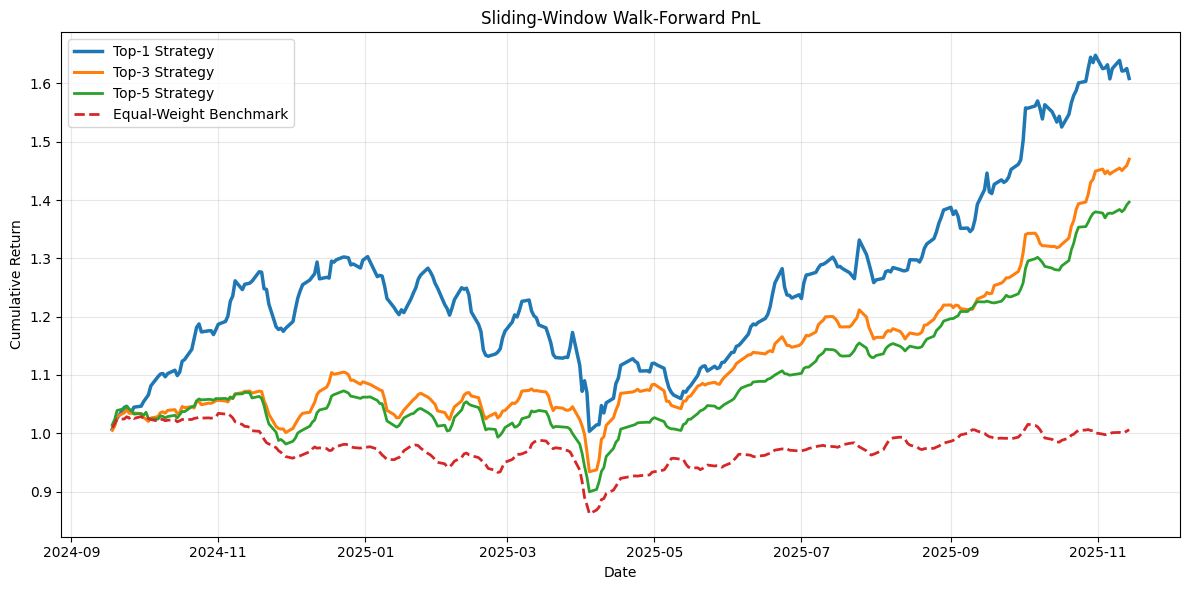

In [13]:
# Equal-weight benchmark: average future_ret across all pairs each day
def equal_weight_pnl(df):
    rows = []
    for d, grp in df.groupby("Date"):
        rows.append({"Date": d, "pnl": grp["future_ret"].mean()})
    return pd.DataFrame(rows).sort_values("Date")

pnl_eq = equal_weight_pnl(pred_df)
cum_eq = cumulative_curve(pnl_eq)

plt.figure(figsize=(12, 6))
plt.plot(cum1["Date"], cum1["cum"], label="Top-1 Strategy", linewidth=2.5)
plt.plot(cum3["Date"], cum3["cum"], label="Top-3 Strategy", linewidth=2.2)
plt.plot(cum5["Date"], cum5["cum"], label="Top-5 Strategy", linewidth=2.0)
plt.plot(cum_eq["Date"], cum_eq["cum"], label="Equal-Weight Benchmark", linewidth=2.0, linestyle="--")
plt.grid(True, alpha=0.3)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Sliding-Window Walk-Forward PnL")
plt.legend()
plt.tight_layout()
plt.show()


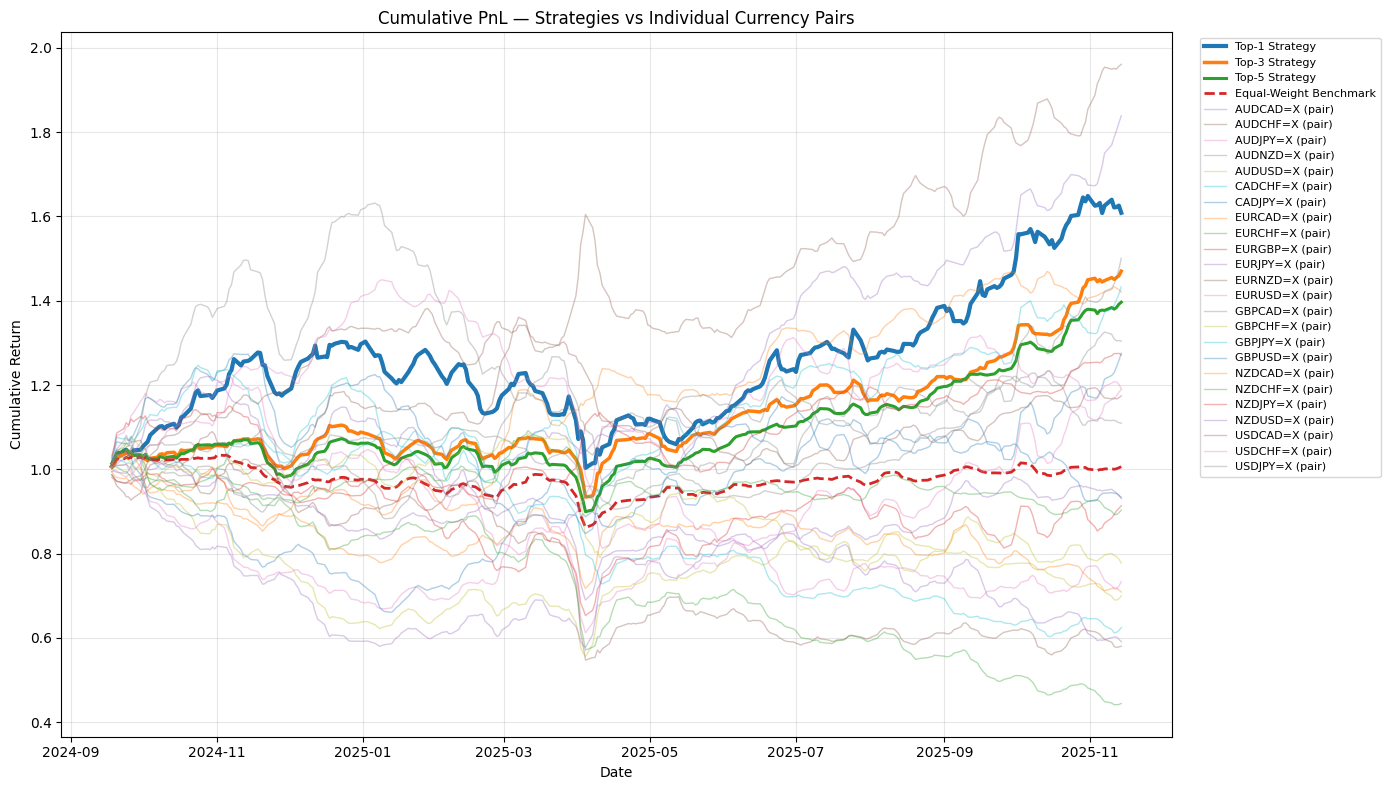

In [14]:
# ============================================
#  ADD INDIVIDUAL PAIR PnL CURVES TO THE PLOT
# ============================================

import matplotlib.pyplot as plt

# --- 1. Compute cumulative PnL for each pair ------------------------

pair_curves = {}

for pair in pairs:
    dfp = pred_df[pred_df["pair"] == pair].sort_values("Date").copy()

    # daily pnl for the pair = its future_ret
    dfp["cum"] = (1 + dfp["future_ret"]).cumprod()

    pair_curves[pair] = dfp


# --- 2. Plot everything --------------------------------------------

plt.figure(figsize=(14, 8))

# Strategy curves (bold)
plt.plot(cum1["Date"], cum1["cum"], label="Top-1 Strategy", linewidth=3)
plt.plot(cum3["Date"], cum3["cum"], label="Top-3 Strategy", linewidth=2.5)
plt.plot(cum5["Date"], cum5["cum"], label="Top-5 Strategy", linewidth=2.2)
plt.plot(cum_eq["Date"], cum_eq["cum"], label="Equal-Weight Benchmark",
         linewidth=2.0, linestyle="--")

# Individual pairs (faint)
for pair, dfp in pair_curves.items():
    plt.plot(
        dfp["Date"], dfp["cum"],
        linewidth=1,
        alpha=0.35,
        label=f"{pair} (pair)"
    )

# --- 3. Styling -----------------------------------------------------

plt.title("Cumulative PnL — Strategies vs Individual Currency Pairs")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True, alpha=0.3)

# Move legend outside plot
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()


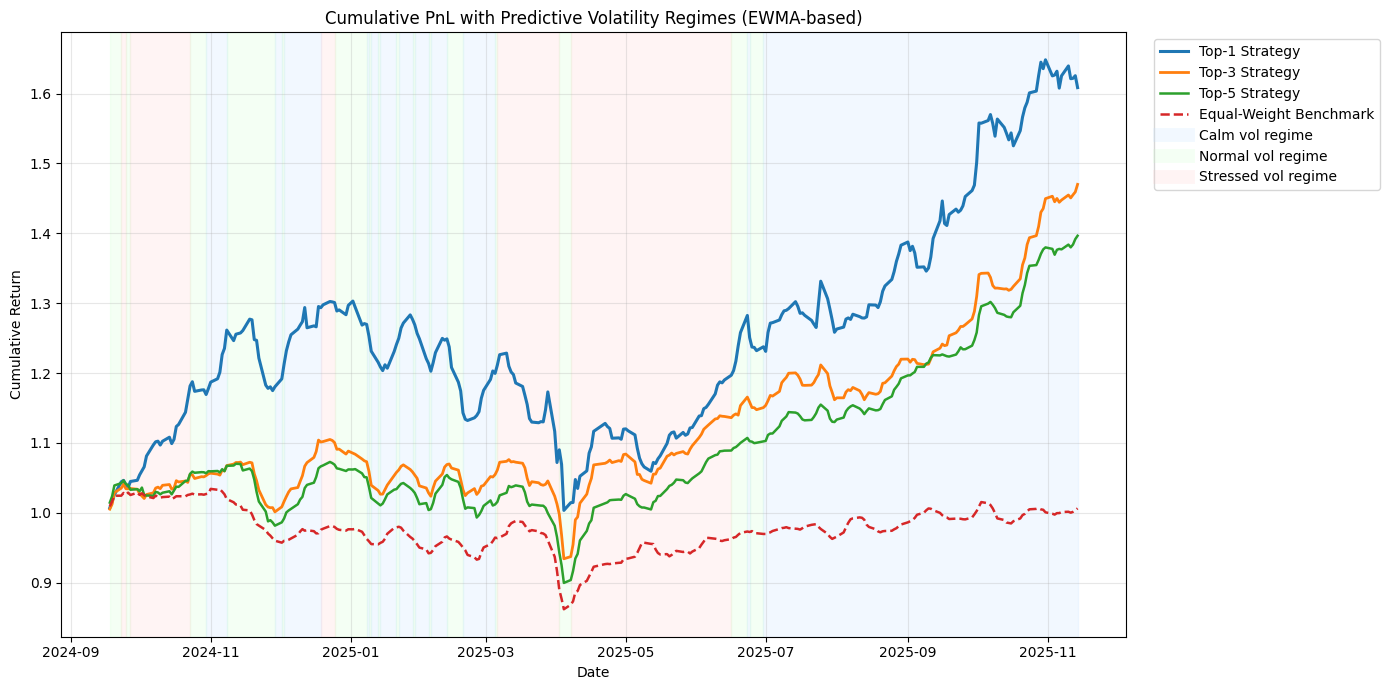

In [15]:
# ============================================================
# DROP-IN: Predictive volatility-regime detection + overlay
# ============================================================
# Assumes you already have:
# - df: wide daily DataFrame with 'Date' and ret_* columns
# - pnl_top1, pnl_top3, pnl_top5, pnl_eq: DataFrames with ['Date', 'pnl']
#   (or you can recompute them upstairs as in your existing notebook)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# 1) Build equal-weight daily index return from ret_* columns
ret_cols = [c for c in df.columns if c.startswith("ret_")]

daily_ret = df[["Date"] + ret_cols].copy()
daily_ret["eq_ret"] = daily_ret[ret_cols].mean(axis=1)

# Restrict to the period where you actually trade (where you have predictions / PnL)
start_date = max(
    daily_ret["Date"].min(),
    min(pnl_top1["Date"].min(), pnl_top3["Date"].min(),
        pnl_top5["Date"].min(), pnl_eq["Date"].min())
)
end_date = min(
    daily_ret["Date"].max(),
    max(pnl_top1["Date"].max(), pnl_top3["Date"].max(),
        pnl_top5["Date"].max(), pnl_eq["Date"].max())
)

mask = (daily_ret["Date"] >= start_date) & (daily_ret["Date"] <= end_date)
daily_ret = daily_ret.loc[mask].reset_index(drop=True)

# 2) Compute EWMA volatility estimate using only past info
#    (this is effectively a one-step-ahead vol forecast)
lam = 0.94  # typical RiskMetrics-style decay

ewma_var = []
prev_var = float(daily_ret["eq_ret"].iloc[0] ** 2)
for r in daily_ret["eq_ret"]:
    var_t = lam * prev_var + (1.0 - lam) * (r ** 2)
    ewma_var.append(var_t)
    prev_var = var_t

daily_ret["ewma_vol"] = np.sqrt(ewma_var)

# 3) Define regimes using ONLY the first half of the sample for thresholds
warmup = max(int(0.5 * len(daily_ret)), 30)  # at least 30 days
base = daily_ret["ewma_vol"].iloc[:warmup]

low_thr = base.quantile(0.33)
high_thr = base.quantile(0.66)

def classify_regime(v, low=low_thr, high=high_thr):
    # 0 = calm, 1 = normal, 2 = stressed
    if v <= low:
        return 0
    elif v >= high:
        return 2
    else:
        return 1

daily_ret["regime"] = daily_ret["ewma_vol"].apply(classify_regime)

# 4) Compress to contiguous segments of the same regime
segments = []
cur_reg = None
seg_start = None

for d, r in zip(daily_ret["Date"], daily_ret["regime"]):
    if cur_reg is None:
        cur_reg = r
        seg_start = d
    elif r != cur_reg:
        segments.append((seg_start, d, cur_reg))
        cur_reg = r
        seg_start = d

# close final segment
segments.append((seg_start, daily_ret["Date"].iloc[-1], cur_reg))

# Colors & labels for regimes
colors = {
    0: (0.8, 0.9, 1.0, 0.25),  # calm: light blue
    1: (0.8, 1.0, 0.8, 0.20),  # normal: light green
    2: (1.0, 0.8, 0.8, 0.20),  # stressed: light red
}
labels = {
    0: "Calm vol regime",
    1: "Normal vol regime",
    2: "Stressed vol regime",
}

# 5) Rebuild cumulative curves, just to be safe they align with [start_date, end_date]
def cumulative_curve(df_pnl):
    df2 = df_pnl.copy()
    df2 = df2[(df2["Date"] >= start_date) & (df2["Date"] <= end_date)]
    df2 = df2.sort_values("Date")
    df2["cum"] = (1.0 + df2["pnl"]).cumprod()
    return df2

cum1    = cumulative_curve(pnl_top1)
cum3    = cumulative_curve(pnl_top3)
cum5    = cumulative_curve(pnl_top5)
cum_eq  = cumulative_curve(pnl_eq)

# 6) Plot PnL curves with predictive regimes overlay
plt.figure(figsize=(14, 7))

# Regime shading (behind lines)
for (start, end, reg) in segments:
    plt.axvspan(start, end, color=colors[reg], zorder=0)

# Strategy curves (on top)
plt.plot(cum1["Date"],   cum1["cum"],   label="Top-1 Strategy", linewidth=2.2)
plt.plot(cum3["Date"],   cum3["cum"],   label="Top-3 Strategy", linewidth=2.0)
plt.plot(cum5["Date"],   cum5["cum"],   label="Top-5 Strategy", linewidth=1.8)
plt.plot(cum_eq["Date"], cum_eq["cum"], label="Equal-Weight Benchmark",
         linewidth=1.8, linestyle="--")

# Build a legend that includes regime patches
handles, leg_labels = plt.gca().get_legend_handles_labels()
for reg in sorted(set(daily_ret["regime"])):
    handles.append(
        plt.Line2D([0], [0],
                   color=colors[reg],
                   lw=10,
                   alpha=colors[reg][3])
    )
    leg_labels.append(labels[reg])

plt.legend(handles, leg_labels, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.title("Cumulative PnL with Predictive Volatility Regimes (EWMA-based)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
